# Fraud Detection

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv("creditcard.csv")

print(df.head())
print(df.shape)
print(df['Class'].value_counts())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

### Check Class Imbalance

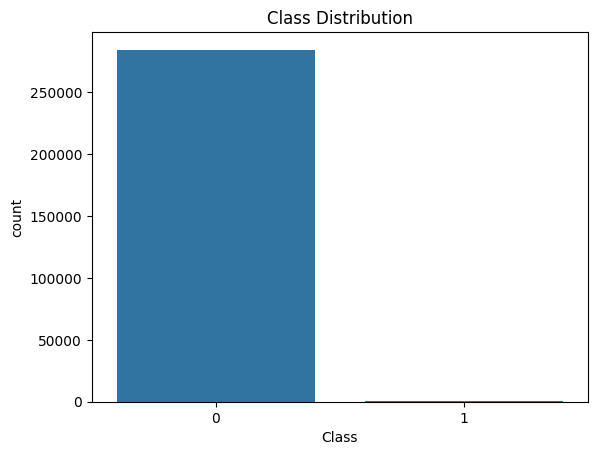

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Class', data=df)
plt.title("Class Distribution")
plt.show()

In [32]:
### There, we can see a massive imbalance... very few fraudulent sctivities. 

### Feature Scaling

In [51]:
# We scale Amount and Time

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1,1))

df.drop(['Time','Amount'], axis=1, inplace=True)

df.insert(0, 'scaled_amount', df.pop('scaled_amount'))
df.insert(1, 'scaled_time', df.pop('scaled_time'))


### Split Data

In [52]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### **Handle Imbalance

In [53]:
# use SMOTE (Synthetic Minority Oversampling) to balance dataset
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Before:", y_train.value_counts())
print("After:", y_train_res.value_counts())

Before: Class
0    227451
1       394
Name: count, dtype: int64
After: Class
0    227451
1    227451
Name: count, dtype: int64


## Training Process

### 1 - Logistic Regression

In [54]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_res, y_train_res)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### 2 - Random Forest

In [55]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_res, y_train_res)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 3 - XGBoost

In [56]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train_res, y_train_res)

C:\Users\malsh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:200: UserWarning: [14:59:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


## Model Evaluation

In [39]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

#### Logistic Model Evaluation

In [67]:
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

print("Logistic Regression Report")
print(classification_report(y_test, y_pred_lr))


Logistic Regression Report
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



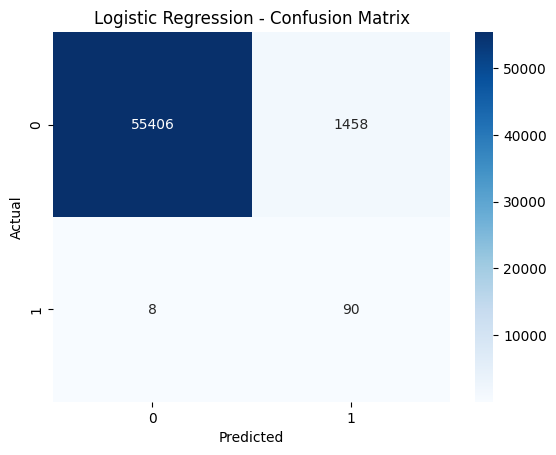

ROC-AUC: 0.9698482164390798


In [57]:
# Confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

roc_auc_lr = roc_auc_score(y_test, y_prob_lr)
print("ROC-AUC:", roc_auc_lr)


#### Random Forest Model Evaluation

In [58]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

In [59]:
print("Random Forest Report")
print(classification_report(y_test, y_pred_rf))

Random Forest Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.82      0.84        98

    accuracy                           1.00     56962
   macro avg       0.93      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



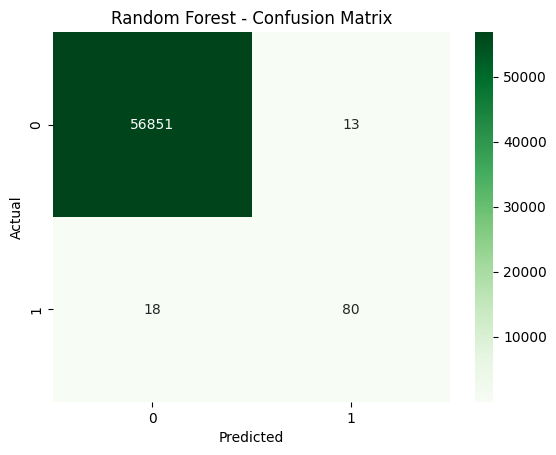

In [60]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [61]:
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
print("ROC-AUC:", roc_auc_rf)

ROC-AUC: 0.9791113670425964


#### XGBoost Model Evaluation

In [62]:
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

In [63]:
print("XGBoost Report")
print(classification_report(y_test, y_pred_xgb))

XGBoost Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.72      0.86      0.78        98

    accuracy                           1.00     56962
   macro avg       0.86      0.93      0.89     56962
weighted avg       1.00      1.00      1.00     56962



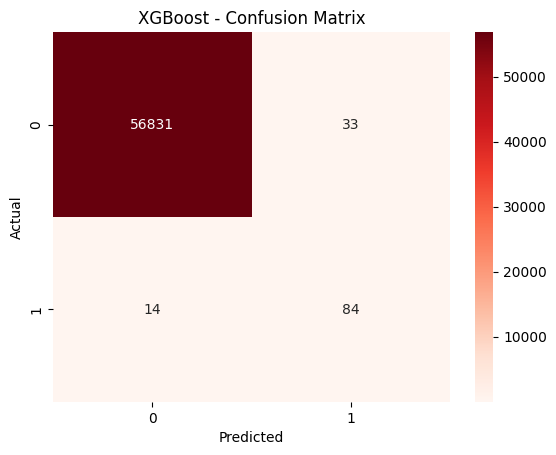

In [64]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Reds")
plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [65]:
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)
print("ROC-AUC:", roc_auc_xgb)

ROC-AUC: 0.980715714113445


### Comparison

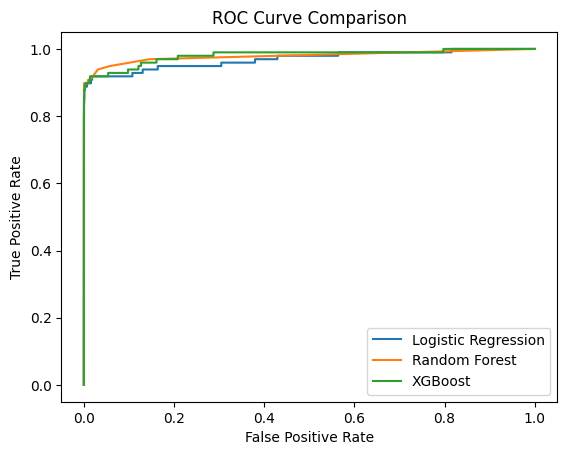

In [66]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [82]:
### After evaluating all models using accuracy, precision, recall, and F1-score, 
# XGBoost achieved the highest F1-score and recall, making it the most suitable model for fraud detection 
# due to its ability to correctly identify fraudulent transactions while maintaining low false negatives.

## Data Cleaning

In [69]:
import pandas as pd

df = pd.read_csv("creditcard.csv")

print(df.shape)
print(df.head())
print(df.isnull().sum())

(284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V

In [70]:
print(df['Class'].value_counts(normalize=True) * 100)

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


#### Remove duplicates

In [73]:
df = df.drop_duplicates()

print("After removing duplicates:", df.shape)

After removing duplicates: (283726, 31)


#### Feature Engineering

In [74]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1,1))

df.drop(['Amount','Time'], axis=1, inplace=True)

df.insert(0, 'scaled_amount', df.pop('scaled_amount'))
df.insert(1, 'scaled_time', df.pop('scaled_time'))

In [75]:
X = df.drop('Class', axis=1)
y = df['Class']

#### Split data - train/test

In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#### Balance data

In [77]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)

print(y_train.value_counts())
print(y_train_bal.value_counts())

Class
0    226602
1       378
Name: count, dtype: int64
Class
0    226602
1    226602
Name: count, dtype: int64


## XGBoost Processing

In [78]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train_bal, y_train_bal)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


from sklearn.metrics import classification_report

y_pred = xgb.predict(X_test)

print(classification_report(y_test, y_pred))

### Hyperparameter Tuning

In [80]:
xgb_tuned = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb_tuned.fit(X_train_bal, y_train_bal)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


#### Final Evaluation

In [81]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_final = xgb_tuned.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall   :", recall_score(y_test, y_pred_final))
print("F1-score :", f1_score(y_test, y_pred_final))

Accuracy : 0.9991717477883904
Precision: 0.7307692307692307
Recall   : 0.8
F1-score : 0.7638190954773869


### Check train vs test performance

In [86]:
y_train_pred = xgb_tuned.predict(X_train_bal)
y_test_pred = xgb_tuned.predict(X_test)

#### Compute metrics

In [87]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred)
    }

train_metrics = get_metrics(y_train_bal, y_train_pred)
test_metrics = get_metrics(y_test, y_test_pred)

print("TRAIN METRICS:", train_metrics)
print("TEST METRICS :", test_metrics)

TRAIN METRICS: {'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0}
TEST METRICS : {'Accuracy': 0.9991717477883904, 'Precision': 0.7307692307692307, 'Recall': 0.8, 'F1': 0.7638190954773869}


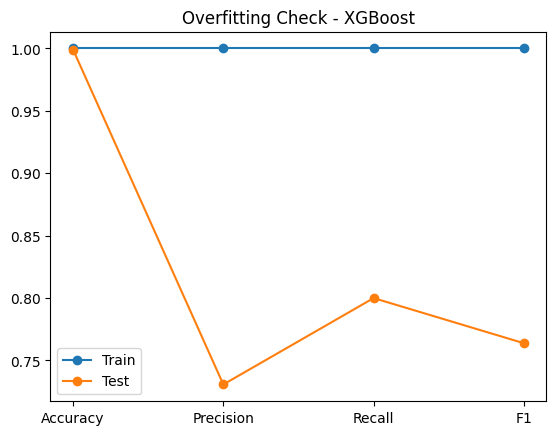

In [88]:
import matplotlib.pyplot as plt

metrics_names = list(train_metrics.keys())

train_values = list(train_metrics.values())
test_values = list(test_metrics.values())

x = range(len(metrics_names))

plt.plot(x, train_values, label="Train", marker='o')
plt.plot(x, test_values, label="Test", marker='o')

plt.xticks(x, metrics_names)
plt.title("Overfitting Check - XGBoost")
plt.legend()
plt.show()

In [89]:
xgb_fixed = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=1,
    eval_metric='logloss',
    random_state=42
)

### Train fixed model

In [91]:
xgb_fixed.fit(X_train_bal, y_train_bal)

y_train_pred_fixed = xgb_fixed.predict(X_train_bal)
y_test_pred_fixed  = xgb_fixed.predict(X_test)

In [92]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def print_metrics(name, y_true, y_pred):
    print(f"\n{name}")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1-score :", f1_score(y_true, y_pred))

print_metrics("TRAIN (Fixed XGB)", y_train_bal, y_train_pred_fixed)
print_metrics("TEST  (Fixed XGB)", y_test, y_test_pred_fixed)


TRAIN (Fixed XGB)
Accuracy : 0.9939254728554912
Precision: 0.994377084299565
Recall   : 0.9934687249009276
F1-score : 0.993922697059804

TEST  (Fixed XGB)
Accuracy : 0.9939731434814789
Precision: 0.19656019656019655
Recall   : 0.8421052631578947
F1-score : 0.3187250996015936


In [96]:
### Use Probability instead of predict

y_prob = xgb_fixed.predict_proba(X_test)[:,1]
threshold = 0.8
y_pred_new = (y_prob > threshold).astype(int)

In [97]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test, y_pred_new))
print("Recall   :", recall_score(y_test, y_pred_new))
print("F1-score :", f1_score(y_test, y_pred_new))

Precision: 0.562962962962963
Recall   : 0.8
F1-score : 0.6608695652173913


In [98]:
import numpy as np

thresholds = np.arange(0.1, 0.95, 0.05)

for t in thresholds:
    y_pred_t = (y_prob > t).astype(int)
    f1 = f1_score(y_test, y_pred_t)
    print(f"Threshold {t:.2f} → F1: {f1:.4f}")

Threshold 0.10 → F1: 0.0423
Threshold 0.15 → F1: 0.0630
Threshold 0.20 → F1: 0.0841
Threshold 0.25 → F1: 0.1087
Threshold 0.30 → F1: 0.1388
Threshold 0.35 → F1: 0.1727
Threshold 0.40 → F1: 0.2157
Threshold 0.45 → F1: 0.2671
Threshold 0.50 → F1: 0.3187
Threshold 0.55 → F1: 0.3712
Threshold 0.60 → F1: 0.4396
Threshold 0.65 → F1: 0.4953
Threshold 0.70 → F1: 0.5467
Threshold 0.75 → F1: 0.6196
Threshold 0.80 → F1: 0.6609
Threshold 0.85 → F1: 0.7353
Threshold 0.90 → F1: 0.7789


In [99]:
threshold = 0.90
y_final = (y_prob > threshold).astype(int)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_final))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.78      0.78      0.78        95

    accuracy                           1.00     56746
   macro avg       0.89      0.89      0.89     56746
weighted avg       1.00      1.00      1.00     56746



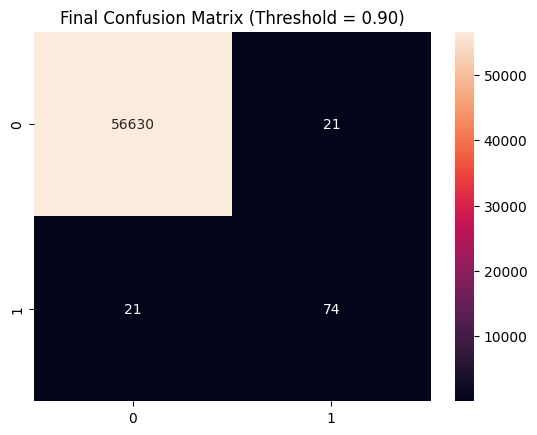

In [103]:
cm = confusion_matrix(y_test, y_final)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Final Confusion Matrix (Threshold = 0.90)")
plt.show()

### Save model & threshold

In [104]:
import pickle

model_data = {
    "model": xgb_fixed,
    "threshold": 0.90
}

pickle.dump(model_data, open("fraud_model_final.pkl", "wb"))